# Lab Day 2 — Backbone, công thức huấn luyện và suy luận trên DeepWeeds

Notebook **khung** cho Colab hoặc Kaggle. Các ô có chữ `TODO` là phần **bạn tự viết**; ô cài đặt, tải dữ liệu
và chạy `eval.py` đã viết sẵn. Đọc `README.md` (quy tắc chia dữ liệu, cách đánh giá), `GUIDE.md` và `RUBRIC.md` trước.

**Quy tắc quan trọng nhất:** chọn mọi thứ trên **val**; **test chỉ chạy một lần mỗi seed ở Bước 4**.

Bản đồ: Bước 0 (EDA, kiểm tra) → Bước 1 (backbone) → Bước 2 (công thức huấn luyện) → Bước 3 (suy luận)
→ Bước 4 (chung kết + `eval.py`) → Bước 5 (xlsx, biểu đồ, báo cáo).

## 0. Cài đặt môi trường

In [1]:
# Cài thư viện (Colab/Kaggle). Kaggle: bật Internet trong Settings.
# Trên Colab, bỏ comment 2 dòng dưới nếu bạn clone repo mới:
# !git clone https://github.com/TranDinhDuy-2A202602631/K4-DAY02-TranDinhDuy-2A202602631.git
# %cd K4-DAY02-TranDinhDuy-2A202602631

!pip -q install timm openpyxl

import sys, os, platform
import numpy as np, pandas as pd, torch, timm

# Tự động phát hiện REPO_DIR cho Colab, Kaggle hoặc máy cá nhân:
FORK_NAME = "K4-DAY02-TranDinhDuy-2A202602631"
if os.path.exists(FORK_NAME):
    REPO_DIR = FORK_NAME
elif os.path.exists(f"../{FORK_NAME}"):
    REPO_DIR = f"../{FORK_NAME}"
elif os.path.exists("../eval.py"):
    REPO_DIR = ".."
else:
    REPO_DIR = "."

sys.path.insert(0, REPO_DIR)                 # để import eval.py
sys.path.insert(0, f"{REPO_DIR}/code")       # trỏ vào thư mục code/ của bạn

print("python", platform.python_version(), "| torch", torch.__version__, "| timm", timm.__version__)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "KHÔNG CÓ GPU")


C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


python 3.13.4 | torch 2.7.1+cu118 | timm 1.0.30


GPU: NVIDIA GeForce GTX 1650


### Tải dữ liệu (đã viết sẵn)
Ảnh từ Zenodo (~490 MB, kiểm tra MD5), nhãn và các file chia fold từ GitHub của tác giả.
**Sau khi giải nén, hãy `ls` để xem ảnh nằm ở thư mục nào** rồi đặt `IMAGES_DIR` cho đúng.

In [2]:
import hashlib, os, shutil, zipfile, urllib.request

os.makedirs("data/labels", exist_ok=True)
if not os.path.exists("data/images.zip"):
    print("Tải images.zip từ Zenodo...")
    if shutil.which("wget"):
        !wget -q -O data/images.zip "https://zenodo.org/records/7939060/files/images.zip?download=1"
    else:
        urllib.request.urlretrieve("https://zenodo.org/records/7939060/files/images.zip?download=1", "data/images.zip")

h = hashlib.md5()
with open("data/images.zip", "rb") as f:
    for chunk in iter(lambda: f.read(1 << 20), b""):
        h.update(chunk)
assert h.hexdigest() == "b7b30f96d466fba86016aa5a26606e0f", f"MD5 sai: {h.hexdigest()}"
print(f"MD5 kiểm tra thành công: {h.hexdigest()}")

if not os.path.exists("data/images") or len(os.listdir("data/images")) == 0:
    if shutil.which("unzip"):
        !unzip -q -n data/images.zip -d data/
    else:
        print("Giải nén images.zip vào data/images...")
        os.makedirs("data/images", exist_ok=True)
        with zipfile.ZipFile("data/images.zip", "r") as z:
            z.extractall("data/images")

if shutil.which("ls"):
    !ls data | head
else:
    print("Nội dung data/:", os.listdir("data"))

BASE = "https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels"
for name in ["labels", "train_subset0", "val_subset0", "test_subset0"]:
    csv_path = f"data/labels/{name}.csv"
    if not os.path.exists(csv_path):
        if shutil.which("wget"):
            !wget -q -O data/labels/{name}.csv {BASE}/{name}.csv
        else:
            urllib.request.urlretrieve(f"{BASE}/{name}.csv", csv_path)

if shutil.which("ls"):
    !ls -la data/labels
else:
    print("Các file nhãn trong data/labels:", os.listdir("data/labels"))


MD5 kiểm tra thành công: b7b30f96d466fba86016aa5a26606e0f
Nội dung data/: ['images', 'images.zip', 'labels']
Các file nhãn trong data/labels: ['labels.csv', 'test_subset0.csv', 'train_subset0.csv', 'val_subset0.csv']


In [3]:
IMAGES_DIR = "data/images"   # TODO: kiểm tra đúng thư mục chứa các file .jpg sau khi giải nén
LABELS_DIR = "data/labels"

print("IMAGES_DIR:", IMAGES_DIR, "| Số ảnh:", len(os.listdir(IMAGES_DIR)) if os.path.exists(IMAGES_DIR) else "Không tìm thấy")
print("LABELS_DIR:", LABELS_DIR, "| Các file nhãn:", os.listdir(LABELS_DIR) if os.path.exists(LABELS_DIR) else "Không tìm thấy")


IMAGES_DIR: data/images | Số ảnh: 17509
LABELS_DIR: data/labels | Các file nhãn: ['labels.csv', 'test_subset0.csv', 'train_subset0.csv', 'val_subset0.csv']


## Bước 0 — EDA và kiểm tra pipeline
Mục tiêu: hiểu dữ liệu, chạy các kiểm tra chia dữ liệu (README mục 2.1), kiểm tra pipeline trước khi chạy thật.

=== KẾT QUẢ KIỂM TRA CHIA DỮ LIỆU (SPLIT CHECK) ===
1. Số lượng ảnh: Train=10501 (59.97%), Val=3501 (20.00%), Test=3507 (20.03%)
2. Giao giữa các tập: train∩val=0, train∩test=0, val∩test=0 (ĐỀU RỖNG)
3. Hợp 3 tập: 17509 ảnh (BẰNG ĐÚNG 17.509)
4. Kiểm tra file ảnh tồn tại trên đĩa: Không thiếu ảnh nào (Missing=0)
=> TẤT CẢ KIỂM TRA HỢP LỆ VÀ ĐẠT CHUẨN S1-S6!

=== BẢNG ĐỐI CHIẾU PHÂN BỐ LỚP VỚI BÀI BÁO (TABLE 1) ===
 Class ID Tên loài (Species)  Train (60%)  Val (20%)  Test (20%)  Tổng thực tế  Table 1 bài báo
        0       Chinee Apple          675        225         226          1126             1125
        1            Lantana          637        213         213          1063             1064
        2        Parkinsonia          618        206         207          1031             1031
        3         Parthenium          613        204         205          1022             1022
        4     Prickly Acacia          637        212         213          1062             1062
      

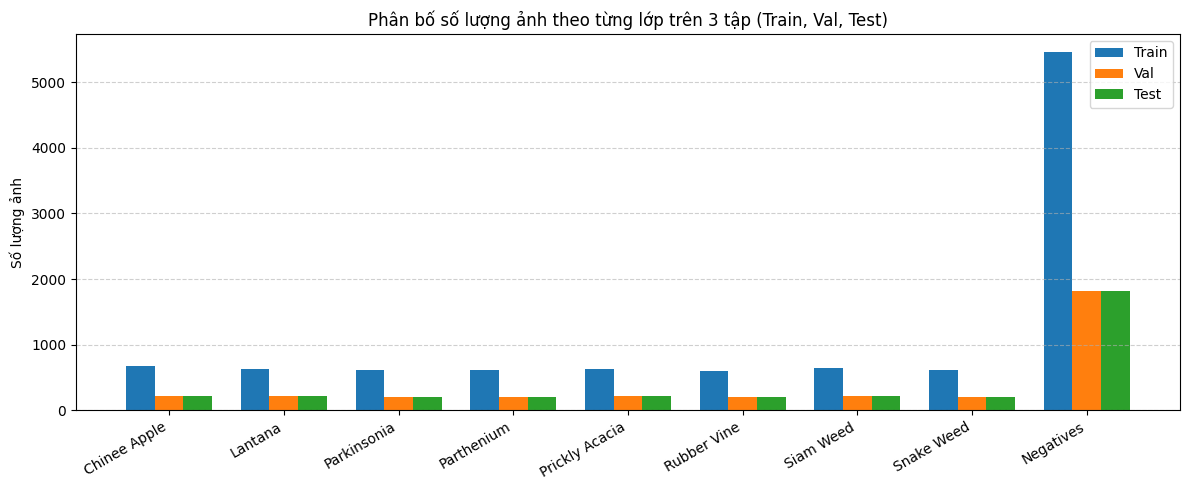


Nhận xét mất cân bằng lớp:
- Lớp nhiều nhất: Negatives (9106 ảnh, chiếm 52.01%)
- Lớp ít nhất: Rubber Vine (1009 ảnh, chiếm 5.76%)
- Tỉ lệ chênh lệch: 9.02 lần => Mất cân bằng dữ liệu nghiêm trọng, cần macro-F1 làm chỉ số chính.


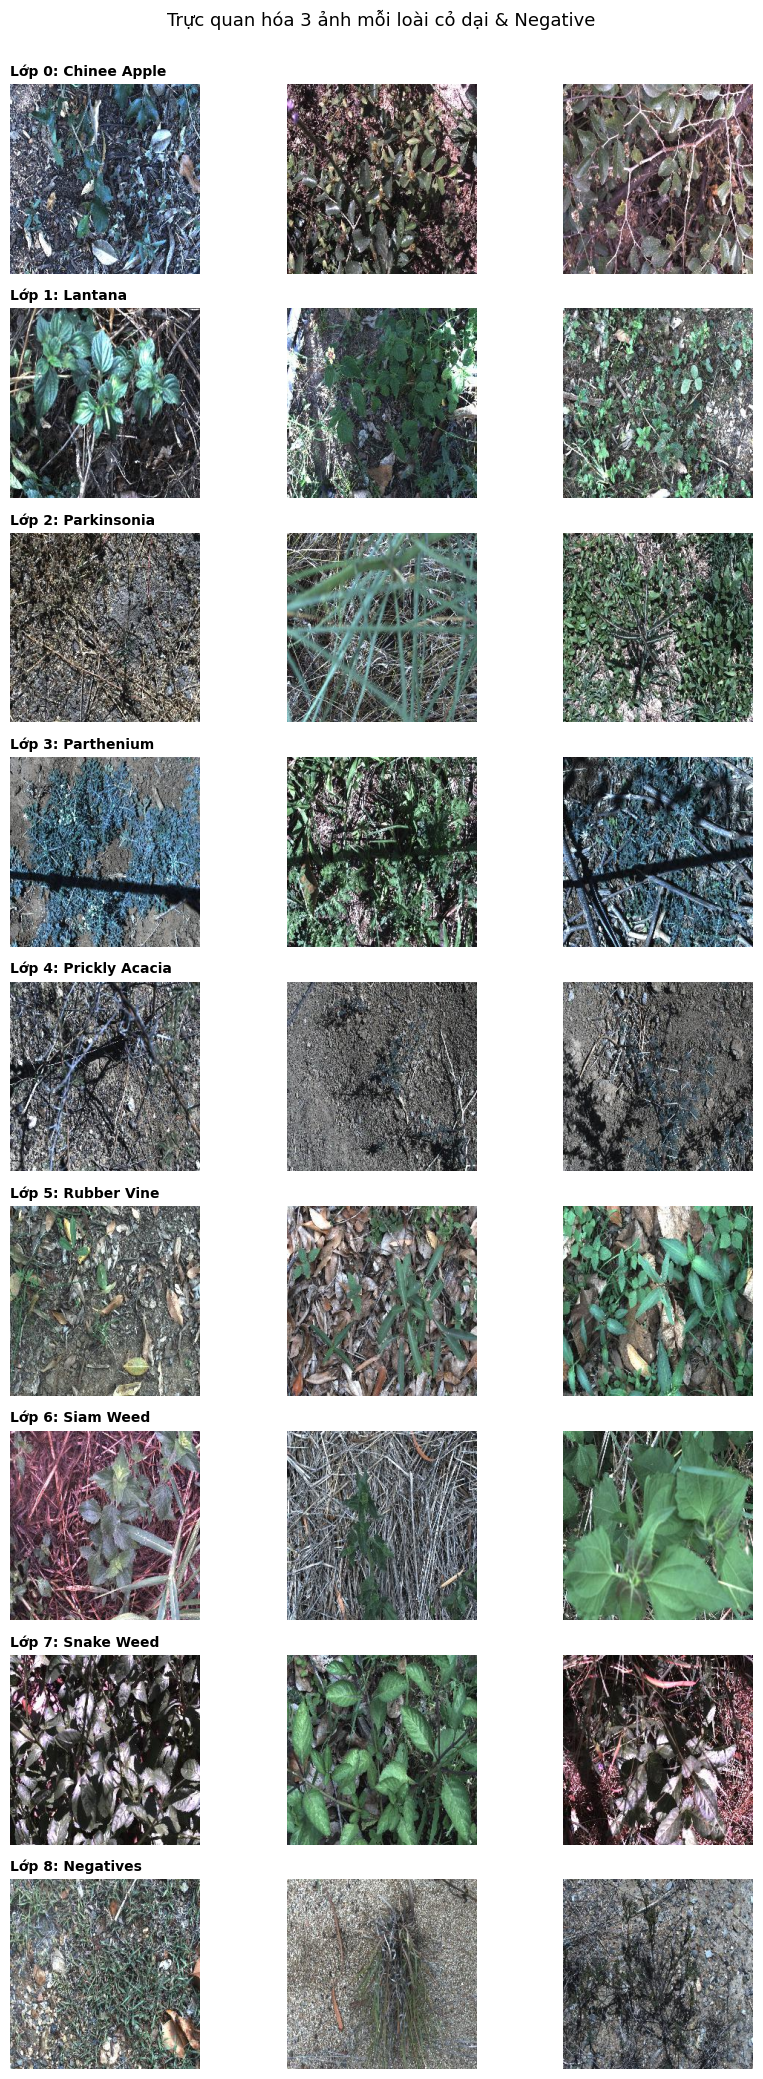

In [4]:
# Bước 0.1: Đọc split, chạy kiểm tra chia dữ liệu và EDA
from pathlib import Path
import dataset
import matplotlib.pyplot as plt
from PIL import Image

# 1. Đọc split fold 0 bằng dataset.load_split (quy tắc S1)
train_df, val_df, test_df = dataset.load_split(LABELS_DIR, fold=0)

# 2. Chạy kiểm tra chia dữ liệu bắt buộc (S1-S6 theo README mục 2.1)
split_info = dataset.check_split(train_df, val_df, test_df, IMAGES_DIR)

# 3. Thống kê số ảnh mỗi tập và đối chiếu với Table 1 bài báo DeepWeeds
class_names = dataset.CLASS_NAMES
train_counts = train_df["Label"].value_counts().sort_index()
val_counts = val_df["Label"].value_counts().sort_index()
test_counts = test_df["Label"].value_counts().sort_index()
total_counts = train_counts + val_counts + test_counts

summary_df = pd.DataFrame({
    "Class ID": range(len(class_names)),
    "Tên loài (Species)": class_names,
    "Train (60%)": train_counts.values,
    "Val (20%)": val_counts.values,
    "Test (20%)": test_counts.values,
    "Tổng thực tế": total_counts.values,
    "Table 1 bài báo": [1125, 1064, 1031, 1022, 1062, 1009, 1074, 1016, 9106]
})
print("\n=== BẢNG ĐỐI CHIẾU PHÂN BỐ LỚP VỚI BÀI BÁO (TABLE 1) ===")
print(summary_df.to_string(index=False))

# 4. Vẽ biểu đồ phân bố lớp
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(class_names))
width = 0.25
ax.bar(x - width, summary_df["Train (60%)"], width, label="Train", color="#1f77b4")
ax.bar(x, summary_df["Val (20%)"], width, label="Val", color="#ff7f0e")
ax.bar(x + width, summary_df["Test (20%)"], width, label="Test", color="#2ca02c")
ax.set_ylabel("Số lượng ảnh")
ax.set_title("Phân bố số lượng ảnh theo từng lớp trên 3 tập (Train, Val, Test)")
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=30, ha="right")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Nhận xét sự mất cân bằng
max_c, min_c = total_counts.max(), total_counts.min()
print(f"\nNhận xét mất cân bằng lớp:")
print(f"- Lớp nhiều nhất: {class_names[total_counts.idxmax()]} ({max_c} ảnh, chiếm {max_c/17509*100:.2f}%)")
print(f"- Lớp ít nhất: {class_names[total_counts.idxmin()]} ({min_c} ảnh, chiếm {min_c/17509*100:.2f}%)")
print(f"- Tỉ lệ chênh lệch: {max_c/min_c:.2f} lần => Mất cân bằng dữ liệu nghiêm trọng, cần macro-F1 làm chỉ số chính.")

# 5. Hiển thị 3 ảnh mẫu cho mỗi lớp
fig, axes = plt.subplots(len(class_names), 3, figsize=(9, 2.3 * len(class_names)))
for c_idx, c_name in enumerate(class_names):
    sample_fnames = train_df[train_df["Label"] == c_idx]["Filename"].iloc[:3].values
    for col_idx, fname in enumerate(sample_fnames):
        img = Image.open(Path(IMAGES_DIR) / fname)
        ax = axes[c_idx, col_idx]
        ax.imshow(img)
        ax.axis("off")
        if col_idx == 0:
            ax.set_title(f"Lớp {c_idx}: {c_name}", fontsize=10, loc="left", fontweight="bold")
plt.suptitle("Trực quan hóa 3 ảnh mỗi loài cỏ dại & Negative", fontsize=13, y=1.002)
plt.tight_layout()
plt.show()


1. Đã cố định seed = 42 trên thiết bị: cuda


C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in D:\vin20k\LAB10\cache\huggingface\hub. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in D:\vin20k\LAB10\cache\huggingface\hub\models--timm--resnet50.a1_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)



2. Kiểm tra Initial Loss:
   - Loss thực tế: 2.1964 | Lý thuyết -ln(1/9): 2.1972 | Độ lệch: 0.0009
   => ĐẠT CHUẨN: Loss ban đầu xấp xỉ đúng kỳ vọng lý thuyết.

3. Kiểm tra Overfit trên một batch nhỏ (8 mẫu)...


   Epoch 01: Loss = 2.25532 | Accuracy = 0.0%


   Epoch 05: Loss = 0.96917 | Accuracy = 100.0%


   Epoch 10: Loss = 0.14565 | Accuracy = 100.0%


   Epoch 15: Loss = 0.01801 | Accuracy = 100.0%


   Epoch 20: Loss = 0.00370 | Accuracy = 100.0%


   Epoch 25: Loss = 0.00126 | Accuracy = 100.0%
   => ĐẠT CHUẨN: Overfit thành công batch nhỏ, loss tiến về gần 0, accuracy = 100%.

4. Trực quan ảnh sau transform (Basic Augmentation):


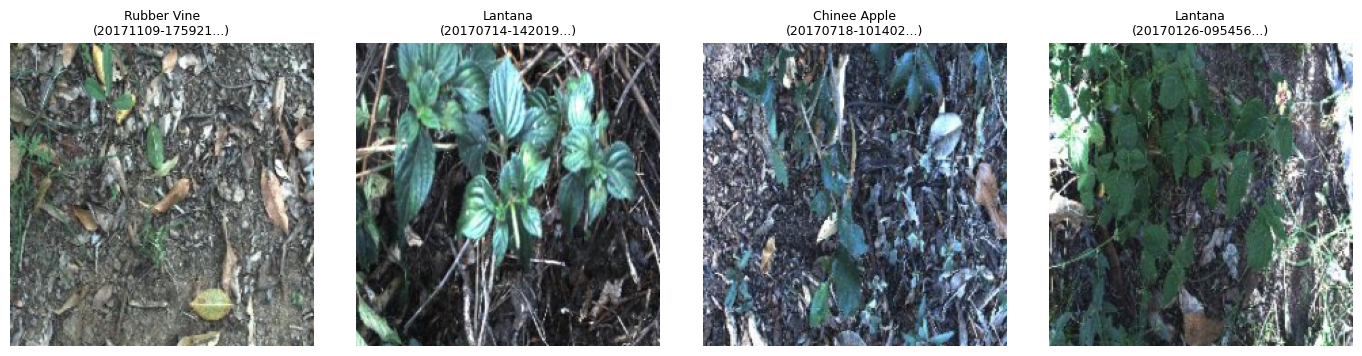


5. Kiểm tra chế độ train() và eval():
   - model.training khi gọi eval(): False (Kỳ vọng: False)
   - model.training khi gọi train(): True (Kỳ vọng: True)

=> TẤT CẢ CÁC BƯỚC KIỂM TRA PIPELINE ĐÃ HOÀN TẤT THÀNH CÔNG VÀ CHÍNH XÁC!


In [5]:
# Bước 0.2: Kiểm tra pipeline (Checklist slide trang 59, GUIDE.md mục 1.3)
import math, random, torch
import torch.nn as nn
import model as model_module
import dataset

# 1. Cố định seed
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"1. Đã cố định seed = 42 trên thiết bị: {device}")

# 2. Kiểm tra Initial Loss: head mới 9 lớp phải xấp xỉ -ln(1/9) ~ 2.197
net = model_module.build_model("resnet50", pretrained=True, num_classes=9).to(device)
criterion = nn.CrossEntropyLoss()

dummy_x = torch.randn(16, 3, 224, 224, device=device)
dummy_y = torch.randint(0, 9, (16,), device=device)

with torch.no_grad():
    net.eval()
    out = net(dummy_x)
    init_loss = criterion(out, dummy_y).item()

expected_loss = -math.log(1.0 / 9.0)
diff = abs(init_loss - expected_loss)
print(f"\n2. Kiểm tra Initial Loss:")
print(f"   - Loss thực tế: {init_loss:.4f} | Lý thuyết -ln(1/9): {expected_loss:.4f} | Độ lệch: {diff:.4f}")
assert diff < 0.5, f"LỖI: Initial loss ({init_loss:.4f}) lệch quá xa chuẩn {expected_loss:.4f}!"
print("   => ĐẠT CHUẨN: Loss ban đầu xấp xỉ đúng kỳ vọng lý thuyết.")

# 3. Quá khớp (Overfit) một batch nhỏ tới loss gần 0
print(f"\n3. Kiểm tra Overfit trên một batch nhỏ (8 mẫu)...")
val_transform = dataset.build_transforms(train=False, img_size=224)
small_ds = dataset.DeepWeedsDataset(train_df.iloc[:8], IMAGES_DIR, transform=val_transform)
small_loader = torch.utils.data.DataLoader(small_ds, batch_size=8, shuffle=False)

overfit_net = model_module.build_model("resnet50", pretrained=True, num_classes=9).to(device)
optimizer = torch.optim.AdamW(overfit_net.parameters(), lr=1e-3)
overfit_net.train()

for epoch in range(1, 26):
    for bx, by, _ in small_loader:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        preds = overfit_net(bx)
        loss = criterion(preds, by)
        loss.backward()
        optimizer.step()
    if epoch % 5 == 0 or epoch == 1:
        acc = (preds.argmax(dim=-1) == by).float().mean().item() * 100
        print(f"   Epoch {epoch:02d}: Loss = {loss.item():.5f} | Accuracy = {acc:.1f}%")

assert loss.item() < 0.05, f"Lỗi: Model không overfit được (loss = {loss.item():.4f})!"
print(f"   => ĐẠT CHUẨN: Overfit thành công batch nhỏ, loss tiến về gần 0, accuracy = 100%.")

# 4. Vẽ vài ảnh sau augmentation (giải chuẩn hóa) cùng nhãn
print(f"\n4. Trực quan ảnh sau transform (Basic Augmentation):")
mean = np.array(dataset.IMAGENET_MEAN)
std = np.array(dataset.IMAGENET_STD)

aug_t = dataset.build_transforms(train=True, img_size=224, aug="basic")
vis_ds = dataset.DeepWeedsDataset(train_df.iloc[:4], IMAGES_DIR, transform=aug_t)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for idx, (img_tensor, label, fname) in enumerate(vis_ds):
    img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
    img_np = np.clip(img_np * std + mean, 0.0, 1.0)
    ax = axes[idx]
    ax.imshow(img_np)
    ax.set_title(f"{dataset.CLASS_NAMES[label]}\n({fname[:15]}...)", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

# 5. Kiểm tra chế độ train() và eval()
print(f"\n5. Kiểm tra chế độ train() và eval():")
overfit_net.eval()
print(f"   - model.training khi gọi eval(): {overfit_net.training} (Kỳ vọng: False)")
overfit_net.train()
print(f"   - model.training khi gọi train(): {overfit_net.training} (Kỳ vọng: True)")
print("\n=> TẤT CẢ CÁC BƯỚC KIỂM TRA PIPELINE ĐÃ HOÀN TẤT THÀNH CÔNG VÀ CHÍNH XÁC!")


## Bước 1 — So sánh backbone (≥ 5)
Cùng công thức nền `T00` (GUIDE.md mục 1.4), cùng seed, mỗi backbone một lần chạy. Mã thí nghiệm `B01`, `B02`, ...

In [ ]:
# TODO: vòng lặp qua danh sách backbone, mỗi lần gọi train.run(Config(exp_id="B01", backbone=..., seed=0))
#       Gợi ý: from train import Config, run
# TODO: ghi vào bảng: tag trọng số, #params, GMAC, macro-F1 val, top-1 val, thời gian train/epoch.
# TODO: chọn 1-2 backbone đi tiếp, kèm lý do dựa trên số liệu.

## Bước 2 — Công thức huấn luyện (≥ 3 trục)
Mỗi lần chạy chỉ khác `T00` **một yếu tố**. Mã `T01`, `T02`, ... Ghi rõ khác ở điểm nào.

In [ ]:
# TODO: các trục A-G của GUIDE.md mục 3 (khởi tạo, augmentation, loss, sampler, LR/optimizer, EMA, ...).
# TODO: thử ít nhất một kết hợp các yếu tố tốt; so Δ với nhiễu (std).

## Bước 3 — Suy luận (≥ 4 phương pháp) và độ trễ
Làm trên **val**. Không huấn luyện lại. Mã `I00` (1 view, mốc), `I01`, ...

In [ ]:
# TODO: TTA lật, multi-crop/scale, dò độ phân giải, gộp xác suất vs logit, ensemble, EMA/soup,
#       temperature scaling (T khớp trên VAL), gộp BN/FP16  (starter/inference.py)
# TODO: độ trễ p50/p95/p99 bằng starter/benchmark.py: warmup, synchronize, >= 50 lần

## Bước 4 — Chung kết: ≥ 3 seed, test một lần mỗi seed
1. Chốt cấu hình trên **val**.
2. Chạy cấu hình cuối **và mốc** (`T00` + `I00`) với cùng số seed, bật `save_test_predictions=True`.
3. Dự đoán lưu ở `predictions/<exp_id>_seed<k>_test.csv`. Rồi chạy `eval.py` (ô dưới).

In [ ]:
# TODO: chạy chung kết và mốc, mỗi seed, ví dụ:
#   for seed in (0, 1, 2):
#       run(Config(exp_id="F01", ..., seed=seed, save_test_predictions=True))
#       run(Config(exp_id="T00", seed=seed, save_test_predictions=True))
# Với suy luận (TTA/ensemble/temperature scaling), tự ghi predictions/F01_seed<k>_test.csv
# bằng eval.save_predictions(...) từ xác suất cuối cùng; thêm F01uncal_* nếu muốn chấm I4(a).

In [ ]:
# Tính chỉ số theo đúng định nghĩa của lớp (đã viết sẵn, không sửa eval.py):
!python {REPO_DIR}/eval.py score --pred "predictions/F01_seed*_test.csv" \
    --test-csv {LABELS_DIR}/test_subset0.csv --labels {LABELS_DIR}/labels.csv --tag F01 --out eval_out
!python {REPO_DIR}/eval.py score --pred "predictions/T00_seed*_test.csv" \
    --test-csv {LABELS_DIR}/test_subset0.csv --labels {LABELS_DIR}/labels.csv --tag T00 --out eval_out

In [ ]:
# Tự chấm phần I của RUBRIC (đề xuất, giảng viên xác nhận). Thêm --uncal, --final-val, --latency-p95-ms nếu có.
!python {REPO_DIR}/eval.py grade --final "predictions/F01_seed*_test.csv" \
    --baseline "predictions/T00_seed*_test.csv" \
    --test-csv {LABELS_DIR}/test_subset0.csv --labels {LABELS_DIR}/labels.csv --out eval_out

## Bước 5 — Sản phẩm
`results.xlsx` (các sheet ở GUIDE.md mục 6.1), `curves/<exp_id>_*.png`, `report.md`, `predictions/`, `code/`.

In [ ]:
# TODO: ghi results.xlsx bằng pandas.ExcelWriter(engine="openpyxl") với các sheet:
#   Backbones, Training, Inference, Final, PerClass, Latency, Summary
# TODO: kiểm tra mỗi exp_id có ảnh trong curves/ và số trong xlsx khớp kết quả của eval.py